# APIs de Noticias

## [Newsdata](https://newsdata.io/search-dashboard)

In [ ]:
import requests
import time
import json
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
url = f"https://newsdata.io/api/1/latest?apikey={newsdata_key}&qInTitle=Mencho&country=mx&language=es,en"

all_results = []
current_page = None

#5 páginas (1000 noticias)
for i in range(100):
    #Añadimos el parámetro page si no es la primera vez
    page_param = f"&page={current_page}" if current_page else ""
    full_url = url + page_param

    response = requests.get(full_url)
    data = response.json()

    if data['status'] == 'success':
        all_results.extend(data['results'])
        current_page = data.get('nextPage') #Guardamos el ID de la siguiente página

        #print(f"Página {i+1} descargada. Total acumulado: {len(all_results)}")

        if not current_page: #Si ya no hay páginas
            break

    time.sleep(1)

In [ ]:
df_newsdata = pd.DataFrame(all_results)

In [ ]:
df_newsdata.columns

Index(['article_id', 'link', 'title', 'description', 'content', 'keywords',
       'creator', 'language', 'country', 'category', 'datatype', 'pubDate',
       'pubDateTZ', 'fetched_at', 'image_url', 'video_url', 'source_id',
       'source_name', 'source_priority', 'source_url', 'source_icon',
       'sentiment', 'sentiment_stats', 'ai_tag', 'ai_region', 'ai_org',
       'ai_summary', 'duplicate'],
      dtype='object')

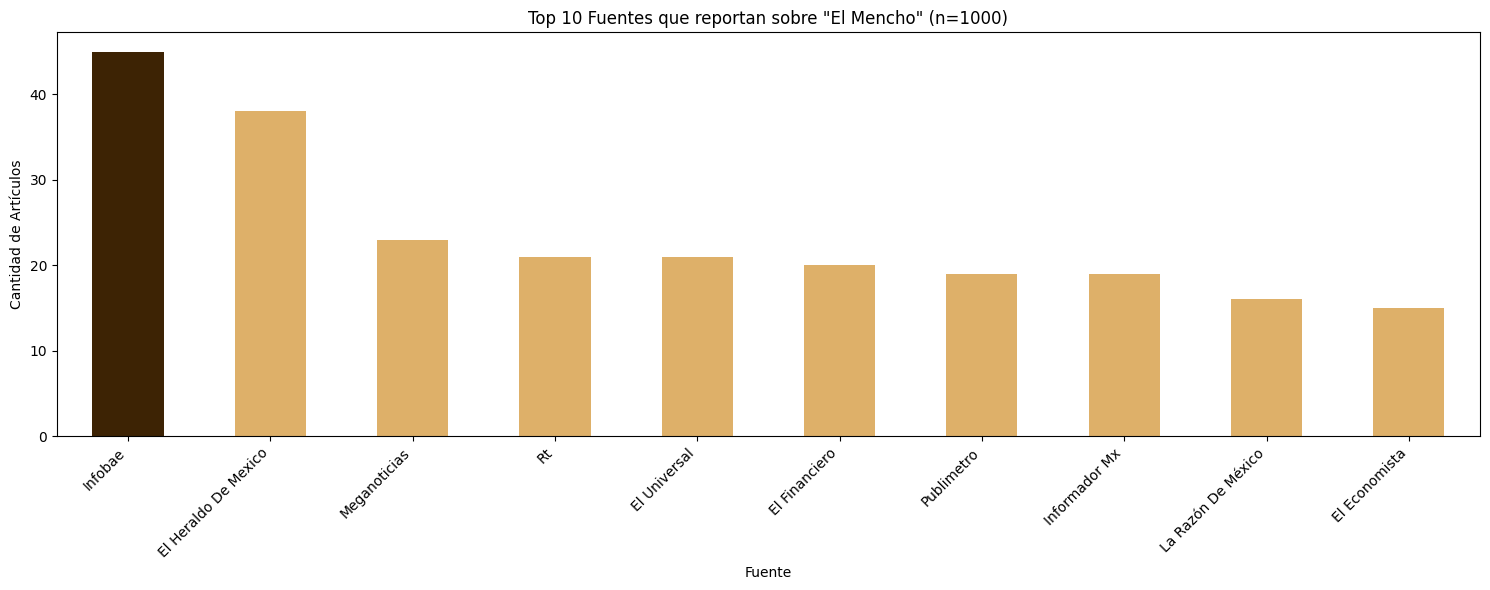

In [ ]:
#Top 10 medios que publicaron noticias
top_sources = df_newsdata['source_name'].value_counts().head(10)

#Visualización
colores_barras = ['#3d2304'] + ['#deb069'] * (len(top_sources) - 1)

plt.figure(figsize=(15, 6))
top_sources.plot(kind='bar', color=colores_barras)

plt.title('Top 10 Fuentes que reportan sobre "El Mencho" (n=1000)')
plt.ylabel('Cantidad de Artículos')
plt.xlabel('Fuente')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

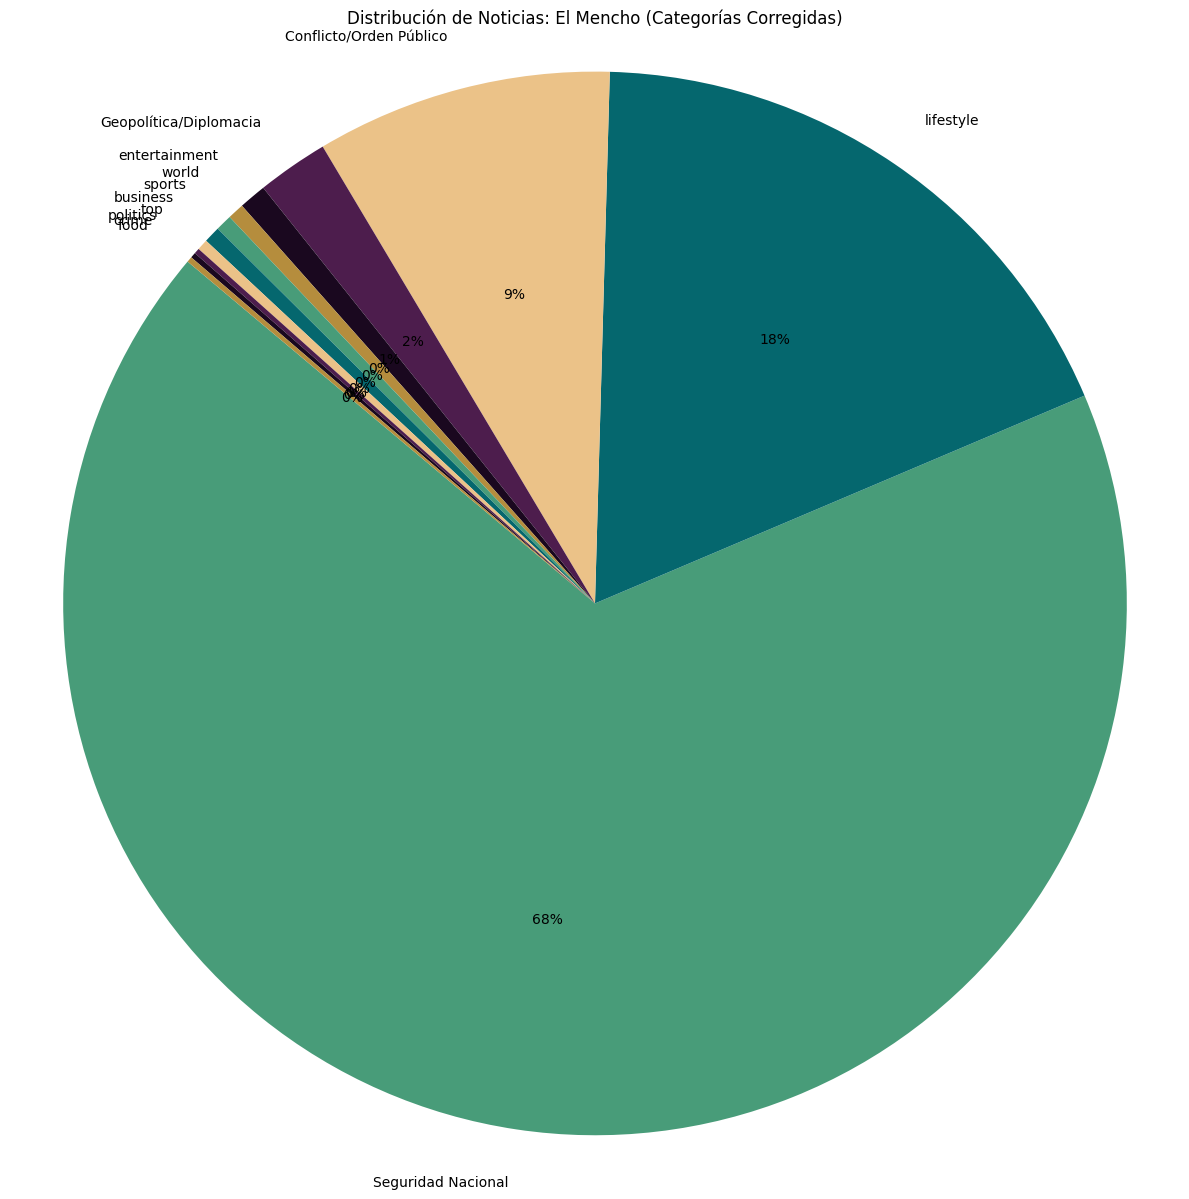

In [ ]:
#lógica de categorías con keywords
def corregir_categoria(row):
    texto = (str(row['title']) + " " + str(row['description'])).lower()

    if any(w in texto for w in ['seguridad', 'militar', 'sedena', 'operativo', 'fgr', 'estado', 'cjng', 'cartel']):
        return 'Seguridad Nacional'
    elif any(w in texto for w in ['geopolítica', 'embajada', 'españa', 'internacional', 'eeuu']):
        return 'Geopolítica/Diplomacia'
    elif any(w in texto for w in ['bloqueo', 'quema', 'violencia', 'ataque', 'enfrentamiento']):
        return 'Conflicto/Orden Público'
    else:
        # Extraer categoría original limpiamente
        cat_orig = row['category'][0] if isinstance(row['category'], list) else row['category']
        return str(cat_orig)

#Procesar los datos
df_newsdata['categoria_real'] = df_newsdata.apply(corregir_categoria, axis=1)
conteo = df_newsdata['categoria_real'].value_counts()

#Visualizacion
plt.figure(figsize=(12, 12))
plt.pie(
    conteo,
    labels=conteo.index,
    autopct='%1.f%%',
    startangle=140,
    colors=['#489c79', '#05676e', '#ebc288', '#4d1d4d', '#1a081f', '#b58d3d']
)

plt.title('Distribución de Noticias: El Mencho (Categorías Corregidas)')
plt.axis('equal')
plt.tight_layout()
plt.show()

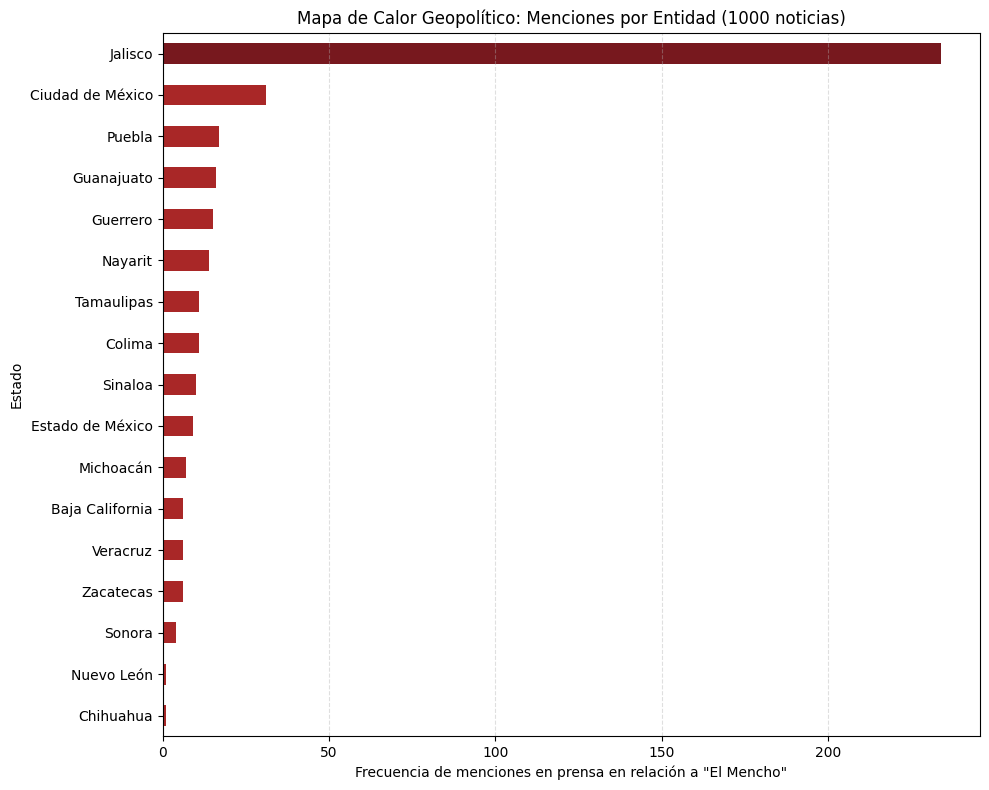

In [ ]:
estados_mexico = {
    'Jalisco': ['jalisco', 'tapalpa', 'guadalajara', 'zapopan'],
    'Michoacán': ['michoacán', 'michoacan', 'morelia', 'uruapan'],
    'Puebla': ['puebla'],
    'Sonora': ['sonora', 'hermosillo'],
    'Colima': ['colima'],
    'Nayarit': ['nayarit', 'tepic'],
    'Guanajuato': ['guanajuato', 'león', 'celaya'],
    'Zacatecas': ['zacatecas'],
    'Sinaloa': ['sinaloa', 'culiacán'],
    'Tamaulipas': ['tamaulipas', 'reynosa', 'matamoros'],
    'Guerrero': ['guerrero', 'acapulco'],
    'Estado de México': ['estado de méxico', 'edomex', 'toluca'],
    'Ciudad de México': ['ciudad de méxico', 'cdmx', 'df'],
    'Veracruz': ['veracruz'],
    'Nuevo León': ['nuevo león', 'monterrey'],
    'Chihuahua': ['chihuahua', 'juárez'],
    'Baja California': ['baja california', 'tijuana']
}

#Conteo de menciones
conteo_geopolitico = {estado: 0 for estado in estados_mexico.keys()}

#Combinamos título y descripción para no perder contexto
df_newsdata['busqueda'] = (df_newsdata['title'].fillna('') + " " + df_newsdata['description'].fillna('')).str.lower()

for index, row in df_newsdata.iterrows():
    for estado, variantes in estados_mexico.items():
        if any(v in row['busqueda'] for v in variantes):
            conteo_geopolitico[estado] += 1

#Solo nos quedamos con estados con menciones
df_geo = pd.Series(conteo_geopolitico).sort_values(ascending=True)
df_geo = df_geo[df_geo > 0]

#Visualización
plt.figure(figsize=(10, 8))
colors = ['#a92727' if x < df_geo.max()*0.3 else '#77181e' for x in df_geo]
df_geo.plot(kind='barh', color=colors)

plt.title('Mapa de Calor Geopolítico: Menciones por Entidad (1000 noticias)')
plt.xlabel('Frecuencia de menciones en prensa en relación a "El Mencho"')
plt.ylabel('Estado')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Finanzas

## [Alpha vantage](https://www.alphavantage.co/)

In [ ]:
!pip install alpha_vantage --quiet

In [ ]:
from alpha_vantage.timeseries import TimeSeries

In [ ]:
ts = TimeSeries(key = alfavantage_key, output_format='pandas')
data = ts.get_daily('AAPL')
data[0]

,1. open,2. high,3. low,4. close,5. volume
date,,,,,
2026-02-23,263.490,269.430,263.381,266.18,37045272.0
2026-02-20,258.970,264.750,258.160,264.58,42070499.0
2026-02-19,262.600,264.480,260.050,260.58,30845294.0
2026-02-18,263.600,266.820,262.450,264.35,34203337.0
2026-02-17,258.050,266.290,255.540,263.88,58469094.0
...,...,...,...,...,...
2025-10-06,257.990,259.070,255.050,256.69,44664118.0
2025-10-03,254.665,259.240,253.950,258.02,49155614.0
2025-10-02,256.575,258.180,254.150,257.13,42630239.0


Generalmente, funciones que permitan datos de muy bajo periodo son de paga, pues permiten automatizar bots de trading.

In [ ]:
data = ts.get_intraday('AAPL', interval='10min')
data[0]

ValueError: Thank you for using Alpha Vantage! This is a premium endpoint. You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly unlock all premium endpoints

In [ ]:
from alpha_vantage.fundamentaldata import FundamentalData

fd = FundamentalData(alfavantage_key, output_format = 'pandas')

data = fd.get_income_statement_annual('AAPL')
data[0]

,fiscalDateEnding,reportedCurrency,grossProfit,totalRevenue,costOfRevenue,costofGoodsAndServicesSold,operatingIncome,sellingGeneralAndAdministrative,researchAndDevelopment,operatingExpenses,...,depreciation,depreciationAndAmortization,incomeBeforeTax,incomeTaxExpense,interestAndDebtExpense,netIncomeFromContinuingOperations,comprehensiveIncomeNetOfTax,ebit,ebitda,netIncome
date,,,,,,,,,,,,,,,,,,,,,
1970-01-01 00:00:00.000000000,2025-09-30,USD,195201000000,416161000000,220960000000,220960000000,133050000000,27601000000,34550000000,62151000000,...,None,11698000000,132729000000,20719000000,None,112010000000,None,132729000000,144427000000,112010000000
1970-01-01 00:00:00.000000001,2024-09-30,USD,180683000000,391035000000,210352000000,210352000000,123216000000,26097000000,31370000000,57467000000,...,None,11445000000,123485000000,29749000000,None,93736000000,None,123216000000,134661000000,93736000000
1970-01-01 00:00:00.000000002,2023-09-30,USD,169148000000,383285000000,214137000000,214137000000,114301000000,24932000000,29915000000,54847000000,...,None,11519000000,113736000000,16741000000,None,96995000000,None,114301000000,125820000000,96995000000
1970-01-01 00:00:00.000000003,2022-09-30,USD,170782000000,394328000000,223546000000,223546000000,119437000000,25094000000,26251000000,51573000000,...,None,11104000000,119103000000,19300000000,None,99803000000,None,119437000000,130541000000,99803000000
1970-01-01 00:00:00.000000004,2021-09-30,USD,152836000000,365817000000,212981000000,212981000000,108949000000,21973000000,21914000000,43887000000,...,None,11284000000,109207000000,14527000000,None,94680000000,None,111852000000,123136000000,94680000000
1970-01-01 00:00:00.000000005,2020-09-30,USD,104956000000,274515000000,169559000000,169559000000,66288000000,19916000000,18752000000,38668000000,...,None,11056000000,67091000000,9680000000,None,57411000000,None,69964000000,81020000000,57411000000
1970-01-01 00:00:00.000000006,2019-09-30,USD,98392000000,260174000000,161782000000,161782000000,63930000000,18245000000,16217000000,34462000000,...,None,12547000000,65737000000,10481000000,None,55256000000,None,69313000000,81860000000,55256000000
1970-01-01 00:00:00.000000007,2018-09-30,USD,101839000000,265595000000,163756000000,163756000000,70898000000,16705000000,14236000000,30941000000,...,None,10903000000,72903000000,13372000000,None,59531000000,None,76143000000,87046000000,59531000000
1970-01-01 00:00:00.000000008,2017-09-30,USD,88186000000,229234000000,141048000000,141048000000,61344000000,15261000000,11581000000,26842000000,...,None,10157000000,64089000000,15738000000,None,48351000000,None,66412000000,76569000000,48351000000


In [ ]:
from alpha_vantage.cryptocurrencies import CryptoCurrencies

cc = CryptoCurrencies(alfavantage_key, output_format='pandas')
data = cc.get_digital_currency_weekly('ETH', 'USD')

data[0]

,1. open,2. high,3. low,4. close,5. volume
date,,,,,
2026-02-24,1956.960000,1958.13000,1812.240000,1855.310000,2.341730e+05
2026-02-22,1965.480000,2038.20000,1905.120000,1956.840000,8.266355e+05
2026-02-15,2088.360000,2146.76000,1895.560000,1965.360000,1.252731e+06
2026-02-08,2268.240000,2395.59000,1742.790000,2088.420000,2.177105e+06
2026-02-01,2814.190000,3041.67000,2218.570000,2268.180000,1.145943e+06
...,...,...,...,...,...
2015-09-13,1.295830,1.30548,0.902832,0.934392,5.238042e+06
2015-09-06,1.319270,1.39615,1.201010,1.297300,5.655837e+06
2015-08-30,1.352590,1.36799,1.061830,1.322110,6.268079e+06


# Neurociencias

## [Openneuro](https://openneuro.org/)

| Técnica | ¿Qué mide? | Resolución Espacial (¿Dónde?) | Resolución Temporal (¿Cuándo?) |
| :--- | :--- | :--- | :--- |
| **fMRI** | Flujo sanguíneo (Efecto BOLD) | **Alta** (Milímetros) | Baja (Segundos) |
| **PET** | Metabolismo de glucosa | Media | Muy Baja (Minutos) |
| **MEG** | Campos magnéticos neuronales | Media / Alta | **Muy Alta** (Milisegundos) |
| **EEG** | Actividad eléctrica (superficie) | Baja | **Muy Alta** (Milisegundos) |
| **iEEG** | Actividad eléctrica (directa/interna) | **Muy Alta** | **Muy Alta** (Milisegundos) |
| **fNIRS** | Oxigenación mediante luz infrarroja | Media | Baja (Segundos) |

88 sujetos divididos en tres grupos (Alzheimer, Demencia Frontotemporal y Sanos)

Fuente: https://openneuro.org/datasets/ds004504/versions/1.0.8

In [ ]:
!pip install openneuro-py --quiet

In [ ]:
import openneuro as on

In [ ]:
on.download(
    dataset='ds004504',
    target_dir='data/bids',
    include=[
        'participants.tsv',
        'dataset_description.json',
        'sub-001/eeg/sub-001_task-eyesclosed_channels.tsv',
        'sub-001/eeg/sub-001_task-eyesclosed_eeg.json',
        'sub-001/eeg/sub-001_task-eyesclosed_eeg.set'
    ]
)


👋 Hello! This is openneuro-py 2026.1.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds004504 …


📁 Traversing directories for ds004504 : 0 entities [00:00, ? entities/s]

📥 Retrieving up to 8 files (5 concurrent downloads). 
✅ Finished downloading ds004504.
 
🧠 Please enjoy your brains.
 


In [ ]:
file_path = '/content/data/bids/participants.tsv'
df = pd.read_csv(file_path, sep='\t')
df

,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22
...,...,...,...,...,...
83,sub-084,F,71,F,24
84,sub-085,M,64,F,26
85,sub-086,M,49,F,26
86,sub-087,M,73,F,24


In [ ]:
file_path_channels = '/content/data/bids/sub-001/eeg/sub-001_task-eyesclosed_channels.tsv'
df_channels = pd.read_csv(file_path_channels, sep='\t')
display(df_channels.head())

,name,type,units
0,Fp1,EEG,microV
1,Fp2,EEG,microV
2,F3,EEG,microV
3,F4,EEG,microV
4,C3,EEG,microV


In [ ]:
file_path_eeg_json = '/content/data/bids/sub-001/eeg/sub-001_task-eyesclosed_eeg.json'

with open(file_path_eeg_json, 'r') as f:
    eeg_json_data = json.load(f)

df_eeg_json = pd.DataFrame([eeg_json_data])
display(df_eeg_json.head())

,PowerLineFrequency,SoftwareFilters,EEGPlacementScheme,EEGReference,CapManufacturersModelName,CapManufacturer,InstitutionAddress,InstitutionalDepartmentName,InstitutionName,TaskName,EEGChannelCount,RecordingType,RecordingDuration,SamplingFrequency,EOGChannelCount,ECGChannelCount,EMGChannelCount
0,50,{'FilterDescription': {'Description': '0.4 - 5...,10-20,A1 A2,EEG 2100,Nihon Kohden,"Arta, Greece",Department of Informatics and Telecommunications,University of Ioannina,eyesclosed,19,continuous,599.8,500,0,0,0


In [ ]:
!pip install mne --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 22.8 MB/s eta 0:00:00


In [ ]:
import mne.io

#ruta al archivo EEG
eeg_file_path = '/content/data/bids/sub-001/eeg/sub-001_task-eyesclosed_eeg.set'

# Cargar el archivo MNE-Python
#'preload=False' is default, can set to True if want to load data into memory
raw_eeg = mne.io.read_raw_eeglab(eeg_file_path, preload=False, verbose=False)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, ...
 chs: 19 EEG
 custom_ref_applied: False
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 500.0 Hz
>


In [ ]:
display(raw_eeg)

<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~26 KiB, data not loaded>

In [ ]:
# 1. Extraer la matriz de datos pura (Canales x Tiempo)
# Necesitas haber puesto preload=True o ejecutar .load_data() antes
raw_eeg.load_data()
data, times = raw_eeg[:, :]

print(f"Forma de la matriz de datos (Canales, Muestras): {data.shape}")
print(f"Primeros 5 valores del primer canal (Fp1): {data[0, :5]}")

Reading 0 ... 299899  =      0.000 ...   599.798 secs...
Forma de la matriz de datos (Canales, Muestras): (19, 299900)
Primeros 5 valores del primer canal (Fp1): [-0.00018989 -0.00018042 -0.00016699 -0.00016021 -0.00015933]


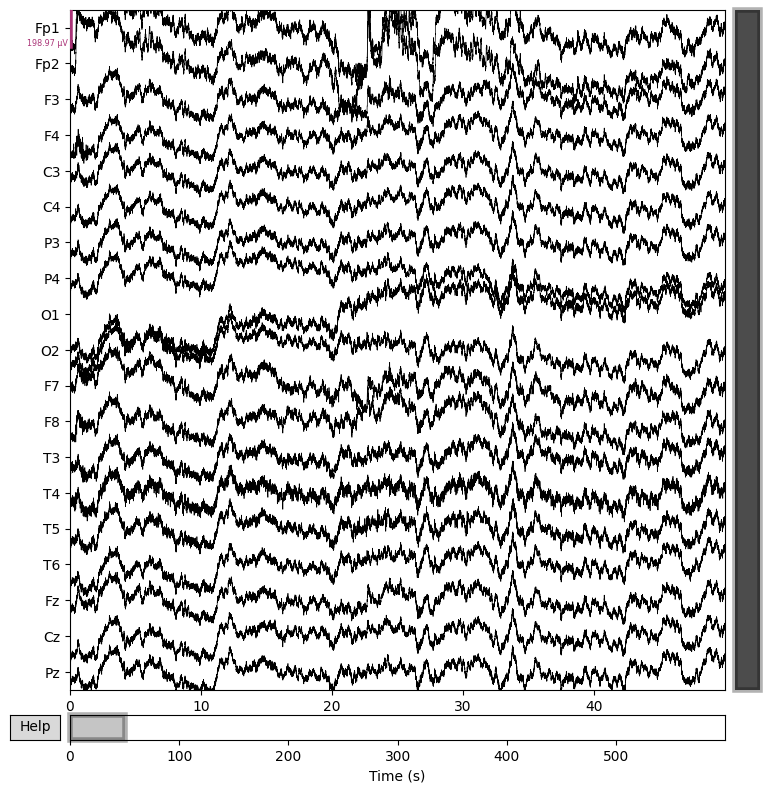

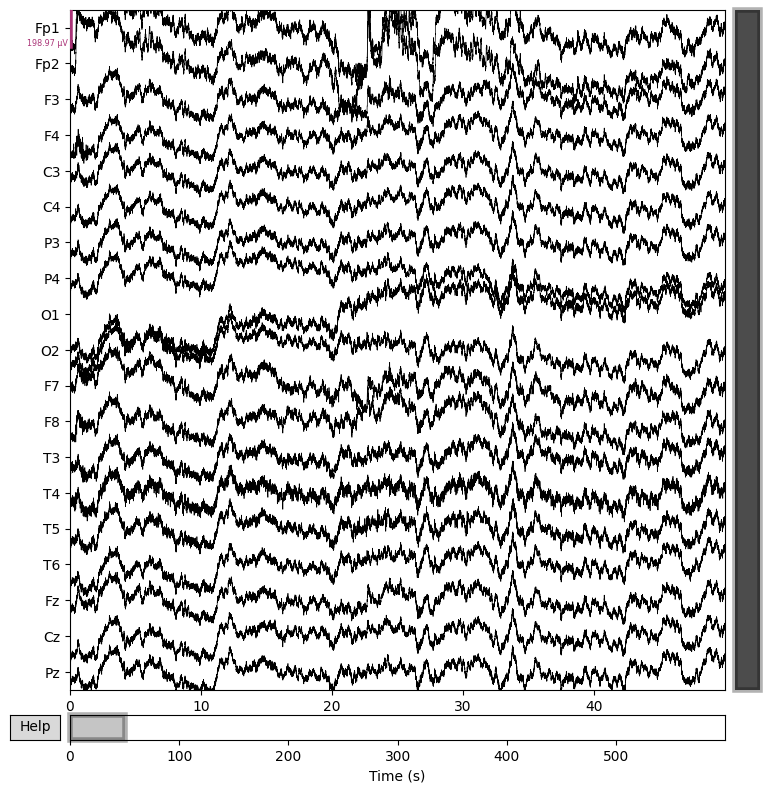

In [ ]:
# Graficar 5 segundos de los 19 canales
raw_eeg.plot(duration=50, n_channels=19, scalings='auto', title="Señales de sub-001")

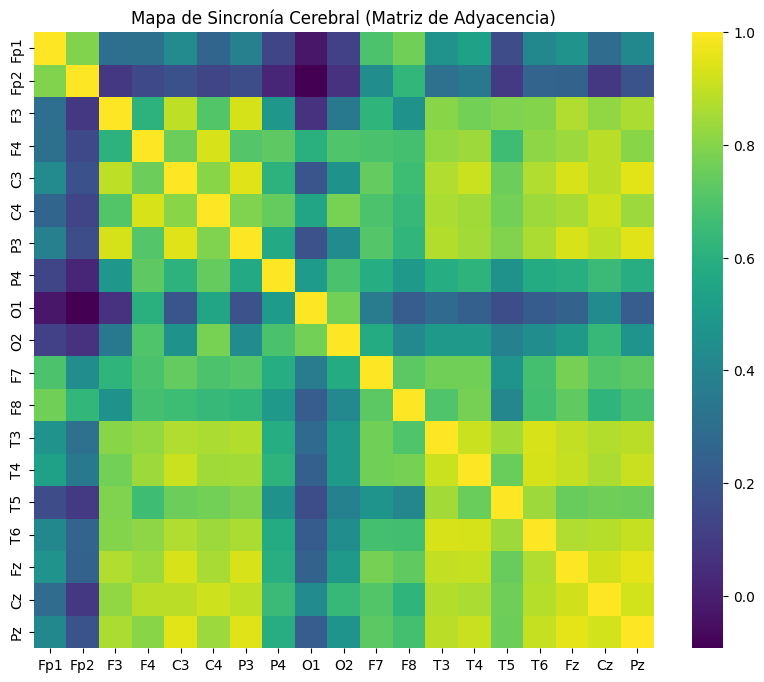

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = np.corrcoef(data)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='viridis',
            xticklabels=raw_eeg.ch_names, yticklabels=raw_eeg.ch_names)
plt.title('Mapa de Sincronía Cerebral')
plt.show()

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


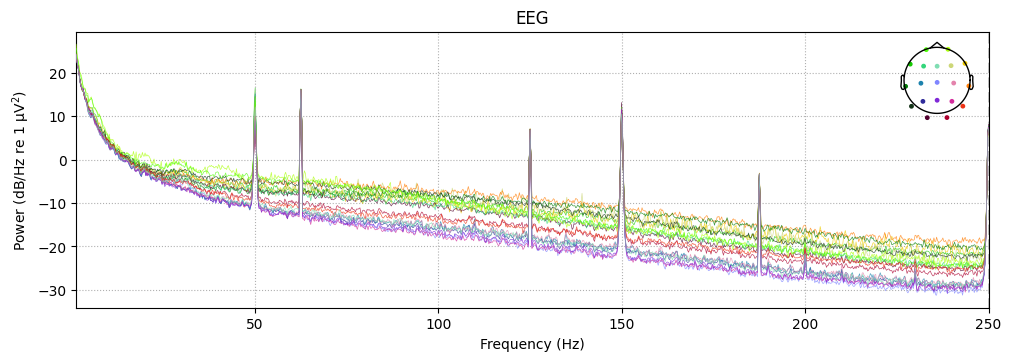

In [ ]:
#Densidad de potencia espectral (PSD)
raw_eeg.compute_psd(fmin=1, fmax=250).plot()
plt.show()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 825 samples (1.650 s)



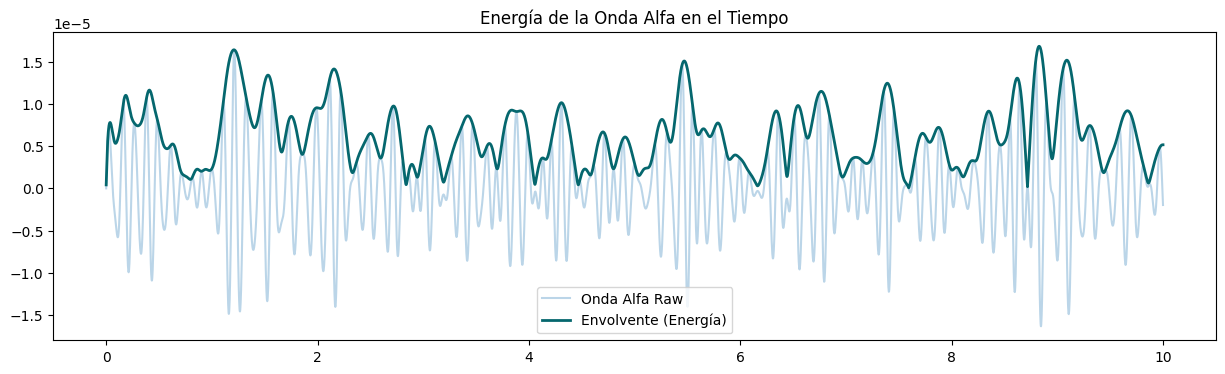

In [ ]:
#Extraer un canal, filtrar en banda Alfa (8-12Hz) y sacar la envolvente
raw_alpha = raw_eeg.copy().filter(8, 12)
data_alpha = raw_alpha.get_data(picks='Fp1')[0]

#Calcular la envolvente (Hilbert Transform)
from scipy.signal import hilbert
envolvente = np.abs(hilbert(data_alpha))

plt.figure(figsize=(15, 4))
plt.plot(raw_eeg.times[:5000], data_alpha[:5000], label='Onda Alfa Raw', alpha=0.3)
plt.plot(raw_eeg.times[:5000], envolvente[:5000], label='Envolvente (Energía)', color='#05676e', linewidth=2)
plt.legend()
plt.title('Energía de la Onda Alfa en el Tiempo')
plt.show()

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 4.096 (s)


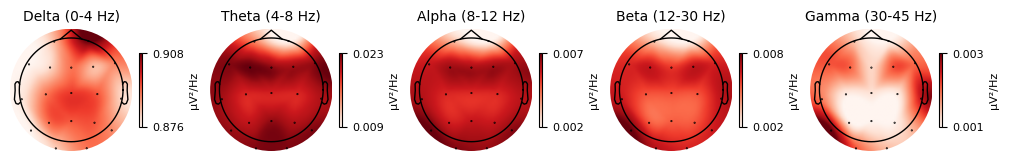

In [ ]:
#Calcula la potencia: Calcula la PSD (Fuerza de las señales en diferentes frecuencias)
raw_eeg.plot_psd_topomap(ch_type='eeg', normalize=True)
plt.show()

## Paciente n° 85

In [ ]:
on.download(
    dataset='ds004504',
    target_dir='data/bids',
    include=[
        'participants.tsv',
        'sub-085/eeg/sub-085_task-eyesclosed*'
    ]
)


👋 Hello! This is openneuro-py 2026.1.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds004504 …


📁 Traversing directories for ds004504 : 0 entities [00:00, ? entities/s]

📥 Retrieving up to 8 files (5 concurrent downloads). 
✅ Finished downloading ds004504.
 
🧠 Please enjoy your brains.
 


NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 4.096 (s)


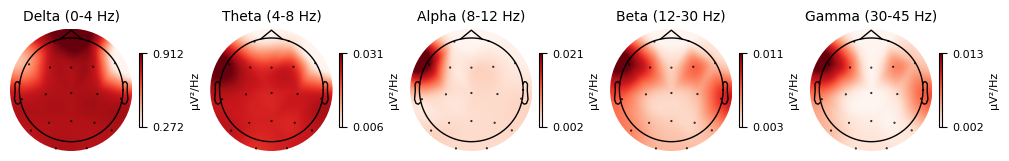

In [ ]:
path_85 = 'data/bids/sub-085/eeg/sub-085_task-eyesclosed_eeg.set'


raw_85 = mne.io.read_raw_eeglab(path_85, preload=True)

#Graficar el mapa de potencia (Topomap) (dónde se concentra la energía en el cerebro del sujeto 85)
raw_85.plot_psd_topomap(ch_type='eeg', normalize=True)
plt.show()

In [ ]:
df_participantes = pd.read_table('data/bids/participants.tsv')
#Paciente 1 y 85
info_sujetos = df_participantes[df_participantes['participant_id'].isin(['sub-001', 'sub-085'])]

print(info_sujetos[['participant_id', 'Group', 'MMSE']])

   participant_id Group  MMSE
0         sub-001     A    16
84        sub-085     F    26


26/30: Es una calificaicón muy alta. Significa que la persona está perfectamente orientada, tiene buena memoria y lenguaje.

12/30: Indica que la persona ya tiene problemas serios para recordar palabras, saber qué día es o realizar cálculos simples.

# [Boxeo](https://www.thesportsdb.com/free_sports_api)

* 30 solicitudes por minuto de manera gratuita

* No es necesario hacer cuenta

* No es necesario conseguir una API_KEY, todo viene en forma de enlace

In [5]:
!pip install thesportsdb --quiet

## v1 API Search (El buscador)

Cuando no sabemos el ID de lo que queremos.

In [20]:
import requests

def test_combate_api(endpoint, query_param, valor):
    api_key = "3"
    url = f"https://www.thesportsdb.com/api/v1/json/{api_key}/{endpoint}.php?{query_param}={valor}"

    try:
        r = requests.get(url)
        data = r.json()

        # Extraer la primera clave del JSON (teams, events, player, o venues)
        key = list(data.keys())[0]

        if data[key]:
            item = data[key][0]
            print(f"✅ ÉXITO en {endpoint}: {item.get('strTeam' or 'strPlayer' or 'strEvent' or 'strVenue', 'Encontrado')}")
            return item
        else:
            print(f"❌ No se encontró nada en {endpoint} para '{valor}'")
    except Exception as e:
        print(f"Error: {e}")

In [21]:
test_combate_api("searchteams", "t", "UFC") #t = equipos (teams)

❌ No se encontró nada en searchteams para 'UFC'


https://www.thesportsdb.com/api/v1/json/123/searchevents.php?e=

In [27]:
test_combate_api("searchevents", "e", "Arsenal_vs_Chelsea") #e,d,s = eventos (events)

✅ ÉXITO en searchevents: Encontrado


{'idEvent': '2401588',
 'idAPIfootball': '1498260',
 'strEvent': 'Arsenal vs Chelsea',
 'strEventAlternate': 'Chelsea @ Arsenal',
 'strFilename': 'EFL Cup 2026-02-03 Arsenal vs Chelsea',
 'strSport': 'Soccer',
 'idLeague': '4570',
 'strLeague': 'EFL Cup',
 'strLeagueBadge': 'https://r2.thesportsdb.com/images/media/league/badge/x1va771565372556.png',
 'strSeason': '2025-2026',
 'strDescriptionEN': '',
 'strHomeTeam': 'Arsenal',
 'strAwayTeam': 'Chelsea',
 'intHomeScore': '1',
 'intRound': '150',
 'intAwayScore': '0',
 'intSpectators': None,
 'strOfficial': '',
 'strTimestamp': '2026-02-03T20:00:00',
 'dateEvent': '2026-02-03',
 'dateEventLocal': '2026-02-03',
 'strTime': '20:00:00',
 'strTimeLocal': '20:00:00',
 'strGroup': '',
 'idHomeTeam': '133604',
 'strHomeTeamBadge': 'https://r2.thesportsdb.com/images/media/team/badge/uyhbfe1612467038.png',
 'idAwayTeam': '133610',
 'strAwayTeamBadge': 'https://r2.thesportsdb.com/images/media/team/badge/yvwvtu1448813215.png',
 'intScore': None,
 '

In [59]:
jugador = test_combate_api("searchplayers", "p", "Conor_McGregor") #p = jugadores (players)
jugador

✅ ÉXITO en searchplayers: UFC Lightweight


{'idPlayer': '34160690',
 'idTeam': '149271',
 'strPlayer': 'Conor McGregor',
 'strTeam': 'UFC Lightweight',
 'strSport': 'Fighting',
 'strThumb': 'https://r2.thesportsdb.com/images/media/player/thumb/xytsvv1447758512.jpg',
 'strCutout': 'https://r2.thesportsdb.com/images/media/player/cutout/08hp1u1604693310.png',
 'strNationality': 'Ireland',
 'dateBorn': '1988-07-14',
 'strStatus': 'Active',
 'strGender': 'Male',
 'strPosition': 'Fighter',
 'relevance': '26.80300521850586'}

In [61]:
from IPython.display import Image, display

url_imagen = jugador["strCutout"]

print(f"{jugador['strPlayer']}:")
display(Image(url=url_imagen, width=300))

Conor McGregor:


In [33]:
jugador['dateBorn']

'1988-07-14'

In [29]:
test_combate_api("searchvenues", "v", "MGM_Grand") #v = estadios / arenas (venues)

✅ ÉXITO en searchvenues: Encontrado


{'idVenue': '21306',
 'idDupe': '23553',
 'strVenue': 'MGM Grand',
 'intLoved': None,
 'strVenueAlternate': '',
 'strVenueSponsor': None,
 'strSport': None,
 'strDescriptionEN': None,
 'strArchitect': None,
 'intCapacity': '0',
 'strCost': '',
 'strCountry': '',
 'strLocation': '',
 'strTimezone': None,
 'intFormedYear': '0',
 'strFanart1': None,
 'strFanart2': None,
 'strFanart3': None,
 'strFanart4': None,
 'strThumb': None,
 'strLogo': None,
 'strMap': '',
 'strWebsite': '',
 'strFacebook': '',
 'strInstagram': '',
 'strTwitter': '',
 'strYoutube': '',
 'strCreativeCommons': 'NO',
 'strLocked': 'unlocked'}

## v1 API Lookup (Consulta por ID)

In [38]:
import requests

def lookup_combate_demo(id_peleador):
    api_key = "3"

    #Historial de peleas (Player Results)
    url_results = f"https://www.thesportsdb.com/api/v1/json/{api_key}/playerresults.php?id={id_peleador}"

    try:
        res = requests.get(url_results).json()
        peleas = res.get("results", [])

        if not peleas:
            print("No se encontraron resultados para este ID.")
            return

        print(f"--- Últimas {len(peleas)} peleas encontradas ---")
        for p in peleas:
            print(f"ID: {p['idEvent']} | {p['strEvent']} | Res: {p.get('strResult', 'N/A')}")

        #Detalles de la pelea mas reciente
        last_event_id = peleas[0]['idEvent']
        url_event = f"https://www.thesportsdb.com/api/v1/json/{api_key}/lookupevent.php?id={last_event_id}"

        ev_res = requests.get(url_event).json()
        detalle = ev_res.get("events", [{}])[0]

        print("\n--- Detalle del último Evento ---")
        print(f"Lugar: {detalle.get('strVenue', 'No disponible')}")
        print(f"Video Highlights: {detalle.get('strVideo', 'No hay video disponible')}")
        print(f"Poster: {detalle.get('strThumb', 'No hay imagen')}")

    except Exception as e:
        print(f"Error: {e}")

#ID de Canelo Alvarez
lookup_combate_demo("34163395") #del link

--- Últimas 5 peleas encontradas ---
ID: 2297359 | Canelo Alvarez vs Terence Crawford | Res: None
ID: 2144989 | Canelo Álvarez vs Edgar Berlanga | Res: None
ID: 1985168 | Canelo Alvarez vs Jaime Munguia | Res: None
ID: 1909629 | Canelo Alvarez vs Jermell Charlo | Res: None
ID: 1809681 | Canelo Alvarez vs John Ryder | Res: None

--- Detalle del último Evento ---
Lugar: Anfield
Video Highlights: 
Poster: None


In [39]:
#Solo muestra 1 porque es la API gratuita
url = "https://www.thesportsdb.com/api/v1/json/3/all_sports.php"
data = requests.get(url).json()

for sport in data['sports']:
    print(f"ID: {sport['idSport']} - Nombre: {sport['strSport']}")

ID: 102 - Nombre: Soccer


In [40]:
data

{'sports': [{'idSport': '102',
   'strSport': 'Soccer',
   'strFormat': 'TeamvsTeam',
   'strSportThumb': 'https://www.thesportsdb.com/images/sports/soccer.jpg',
   'strSportThumbBW': 'https://www.thesportsdb.com/images/sports/bw/soccer.jpg',
   'strSportIconGreen': 'https://www.thesportsdb.com/images/icons/sports/soccer.png',
   'strSportDescription': "Association football, more commonly known as football or soccer, is a team sport played between two teams of eleven players with a spherical ball. It is played by 250 million players in over 200 countries and dependencies, making it the world's most popular sport. The game is played on a rectangular field with a goal at each end. The object of the game is to score by getting the ball into the opposing goal.\r\n\r\nPlayers are not allowed to touch the ball with their hands or arms while it is in play, unless they are goalkeepers (and then only when within their penalty area). Other players mainly use their feet to strike or pass the ball

In [42]:
#Filtrar ligas que sean de "Fighting" o "Boxing"
url = "https://www.thesportsdb.com/api/v1/json/3/search_all_leagues.php?s=Fighting"
data = requests.get(url).json()

data

{'countries': [{'idLeague': '4604',
   'idAPIfootball': None,
   'idAPIfootballv3': None,
   'strSport': 'Fighting',
   'strLeague': 'Jungle Fight',
   'strLeagueAlternate': '',
   'intDivision': '1',
   'idCup': '0',
   'strCurrentSeason': '2025',
   'intFormedYear': '2003',
   'dateFirstEvent': None,
   'strGender': 'Male',
   'strCountry': 'Brazil',
   'strWebsite': 'www.junglefc.com.br',
   'strFacebook': 'www.facebook.com/junglefc',
   'strInstagram': 'instagram.com/junglefcoficial/',
   'strTwitter': 'www.twitter.com/junglefc',
   'strYoutube': '',
   'strRSS': '',
   'strDescriptionEN': 'Jungle Fight is a Brazilian mixed martial arts and kickboxing promotion. It was created in 2003. The name is derived from its origin, the Amazonas state in Brazil. \r\n\r\nJungle Fight was founded by pioneering MMA fighter and long-time Brazilian Jiu Jitsu black belt Wallid Ismail and Japanese professional wrestler Antonio Inoki. The organization was created in 2003 and its first event was in Ma

In [45]:
#Todos los paises de la API
url = "https://www.thesportsdb.com/api/v1/json/3/all_countries.php"
data = requests.get(url).json()

for country in data['countries']:
    print(f"{country['name_en']}")

Andorra
United Arab Emirates
Afghanistan
Antigua and Barbuda
Anguilla
Albania
Armenia
Angola
Antarctica
Argentina
American Samoa
Austria
Australia
Aruba
Aland
Azerbaijan
Bosnia and Herzegovina
Barbados
Bangladesh
Belgium
Burkina Faso
Bulgaria
Bahrain
Burundi
Benin
Saint Barthelemy
Bermuda
Brunei
Bolivia
Bonaire
Brazil
Bahamas
Bhutan
Bouvet Island
Botswana
Belarus
Belize
Canada
Cocos Keeling Islands
DR Congo
Central African Republic
Congo
Switzerland
Ivory Coast
Cook Islands
Chile
Cameroon
China
Colombia
Costa Rica
Cuba
Cape Verde
Curacao
Christmas Island
Cyprus
Czechia
Germany
Djibouti
Denmark
Dominica
Dominican Republic
Algeria
Ecuador
Estonia
Egypt
Western Sahara
England
Eritrea
Spain
Ethiopia
Europe
Finland
Fiji
Falkland Islands
Micronesia
Faroe Islands
France
Gabon
United Kingdom
Grenada
Georgia
French Guiana
Guernsey
Ghana
Gibraltar
Greenland
Gambia
Guinea
Guadeloupe
Equatorial Guinea
Greece
South Georgia
Guatemala
Guam
Guinea-Bissau
Guyana
Hong Kong
Heard and McDonald Islands
Hon

In [52]:
#Todas las ligas (gratuita sale solo futbol, ie, 1 resultado)
url = "https://www.thesportsdb.com/api/v1/json/3/all_leagues.php"
data = requests.get(url).json()

for league in data['leagues']:
    print(f"Liga: {league['strLeague']} | Deporte: {league['strSport']} | ID: {league['idLeague']}")

Liga: English Premier League | Deporte: Soccer | ID: 4328
Liga: English League Championship | Deporte: Soccer | ID: 4329
Liga: Scottish Premier League | Deporte: Soccer | ID: 4330
Liga: German Bundesliga | Deporte: Soccer | ID: 4331
Liga: Italian Serie A | Deporte: Soccer | ID: 4332
Liga: French Ligue 1 | Deporte: Soccer | ID: 4334
Liga: Spanish La Liga | Deporte: Soccer | ID: 4335
Liga: Greek Superleague Greece | Deporte: Soccer | ID: 4336
Liga: Dutch Eredivisie | Deporte: Soccer | ID: 4337
Liga: Belgian Pro League | Deporte: Soccer | ID: 4338
